In [1]:
#pip install pandas scikit-learn matplotlib seaborn joblib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import joblib

In [3]:
# Load the dataset
train_data = pd.read_csv(r"C:\Users\unnati sutradhar\Downloads\internship\housepriceprediction\house-prices-advanced-regression-techniques\train.csv")  # Ensure this path is correct

# Display the first few rows to understand the data
print(train_data.head())

# Display basic info and check for missing values
print(train_data.info())

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

In [4]:
# Select relevant features and target variable
features = ['GrLivArea', 'BedroomAbvGr', 'FullBath']
target = 'SalePrice'

data = train_data[features + [target]] # Select the required columns

# Check for missing values
print("Missing values:\n", data.isnull().sum())

# Handle missing values (if any)
data = data.dropna()

Missing values:
 GrLivArea       0
BedroomAbvGr    0
FullBath        0
SalePrice       0
dtype: int64


In [5]:
# Define the input (X) and target (y)
X = data[features]
y = data[target]

# Split into training and testing sets (80%-20% split)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape}")
print(f"Validation set size: {X_val.shape}")

Training set size: (1168, 3)
Validation set size: (292, 3)


In [6]:
# Initialize and train the Linear Regression model
model = LinearRegression() 
model.fit(X_train, y_train)

print("Model training completed successfully.")

Model training completed successfully.


In [7]:
# Make predictions on the validation set
y_pred = model.predict(X_val)

# Evaluate the model
mae = mean_absolute_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

print(f"Mean Absolute Error (MAE): {mae}")
print(f"R-squared (R²): {r2}")

Mean Absolute Error (MAE): 35788.0612924363
R-squared (R²): 0.6341189942328371


In [8]:
# Display the coefficients for each feature
coefficients = pd.DataFrame({'Feature': features, 'Coefficient': model.coef_})
print("\nModel Coefficients:\n", coefficients)

# Display the intercept (bias)
print(f"Intercept (bias): {model.intercept_}")


Model Coefficients:
         Feature   Coefficient
0     GrLivArea    104.026307
1  BedroomAbvGr -26655.165357
2      FullBath  30014.324109
Intercept (bias): 52261.74862694455


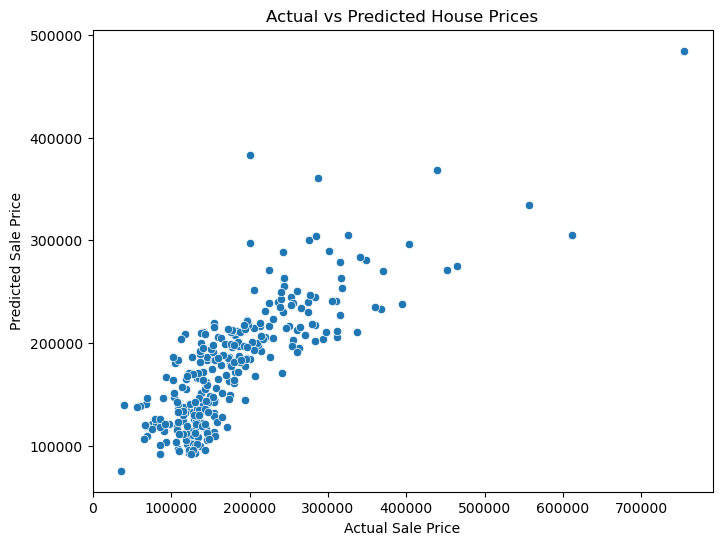

In [9]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_val, y=y_pred)
plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

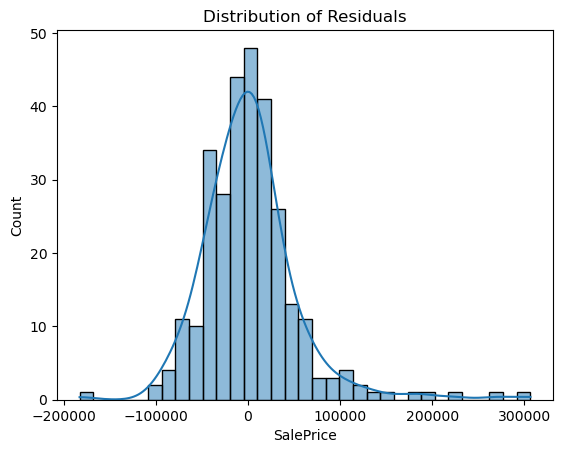

In [10]:
residuals = y_val - y_pred
sns.histplot(residuals, kde=True)
plt.title("Distribution of Residuals")
plt.show()

In [11]:
# Load the test dataset
test_data = pd.read_csv(r"C:\Users\unnati sutradhar\Downloads\internship\housepriceprediction\house-prices-advanced-regression-techniques\test.csv")

# Check for missing values in test data and fill if necessary
print(test_data[features].isnull().sum())
X_test_final = test_data[features].fillna(0)

GrLivArea       0
BedroomAbvGr    0
FullBath        0
dtype: int64


In [12]:
# Predict house prices for the test dataset
predicted_prices = model.predict(X_test_final)

In [13]:
# Create the submission DataFrame
submission = pd.DataFrame({
    'Id': test_data['Id'],        # Use Id from the test data
    'SalePrice': predicted_prices # Predicted house prices
})

# Save the submission file
submission.to_csv('final_submission.csv', index=False)

print("Submission file 'final_submission.csv' created successfully!")

Submission file 'final_submission.csv' created successfully!


In [14]:
# Display the first few rows to verify the submission file
print(submission.head())

     Id      SalePrice
0  1461  122173.313104
1  1462  140561.538683
2  1463  201783.754896
3  1464  199183.097221
4  1465  192133.739106


In [15]:
# Save the trained model for future use
joblib.dump(model, 'house_price_model.pkl')
print("Trained model saved as 'house_price_model.pkl'.")

Trained model saved as 'house_price_model.pkl'.


In [16]:
# Load the saved model
loaded_model = joblib.load('house_price_model.pkl')

# Example prediction for a new house
sample_data = np.array([[2000, 3, 2]])  # Example: 2000 sqft, 3 bedrooms, 2 bathrooms
predicted_price = loaded_model.predict(sample_data)

print(f"Predicted Price for the house: ${predicted_price[0]:,.2f}")

Predicted Price for the house: $240,377.51


C:\Users\unnati sutradhar\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
